In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

In [4]:
df = pd.read_excel("venturi.xlsx")

df.head()

,P1 - throat_length (mm),P2 - diverging_length (mm),P3 - converging_length (mm),P4 - throat_dia (mm),P5 - inlet_dia (mm),P6 - outlet_dia (mm),P11 - mass_flow_rate-op (kg s^-1),P15 - p_inlet-op (Pa),P16 - p_outlet-op (Pa),P17 - v_max-op (m s^-1)
0,40.166667,292.5,132.966667,51.5,83.333333,110.533333,-0.066694,46.697654,-0.001476,26.995272
1,56.833333,251.5,111.966667,68.3,109.733333,97.733333,-0.115664,85.990158,0.000000,26.975095
2,54.500000,258.5,144.166667,60.7,116.133333,92.666667,-0.129583,193.721620,0.000000,38.072629
3,60.833333,291.5,114.766667,63.3,80.400000,112.666667,-0.062081,-6.149937,-0.006353,16.698667
4,55.166667,209.5,89.100000,49.9,100.400000,118.266667,-0.096872,247.199060,-1.178567,43.060847


In [5]:
df.columns = [

    "Throat_Length",
    "Diverging_Length",
    "Converging_Length",
    "Throat_Diameter",
    "Inlet_Diameter",
    "Outlet_Diameter",

    "Mass_Flow",
    "Inlet_Pressure",
    "Outlet_Pressure",
    "Maximum_Velocity"

]

df.head()

,Throat_Length,Diverging_Length,Converging_Length,Throat_Diameter,Inlet_Diameter,Outlet_Diameter,Mass_Flow,Inlet_Pressure,Outlet_Pressure,Maximum_Velocity
0,40.166667,292.5,132.966667,51.5,83.333333,110.533333,-0.066694,46.697654,-0.001476,26.995272
1,56.833333,251.5,111.966667,68.3,109.733333,97.733333,-0.115664,85.990158,0.000000,26.975095
2,54.500000,258.5,144.166667,60.7,116.133333,92.666667,-0.129583,193.721620,0.000000,38.072629
3,60.833333,291.5,114.766667,63.3,80.400000,112.666667,-0.062081,-6.149937,-0.006353,16.698667
4,55.166667,209.5,89.100000,49.9,100.400000,118.266667,-0.096872,247.199060,-1.178567,43.060847


In [6]:
print("Shape of Dataset :", df.shape)

print("\n")

print(df.info())

Shape of Dataset : (149, 10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Throat_Length      149 non-null    float64
 1   Diverging_Length   149 non-null    float64
 2   Converging_Length  149 non-null    float64
 3   Throat_Diameter    149 non-null    float64
 4   Inlet_Diameter     149 non-null    float64
 5   Outlet_Diameter    149 non-null    float64
 6   Mass_Flow          149 non-null    float64
 7   Inlet_Pressure     149 non-null    float64
 8   Outlet_Pressure    149 non-null    float64
 9   Maximum_Velocity   149 non-null    float64
dtypes: float64(10)
memory usage: 11.8 KB
None


In [7]:
print(df.isnull().sum())

Throat_Length        0
Diverging_Length     0
Converging_Length    0
Throat_Diameter      0
Inlet_Diameter       0
Outlet_Diameter      0
Mass_Flow            0
Inlet_Pressure       0
Outlet_Pressure      0
Maximum_Velocity     0
dtype: int64


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Throat_Length,149.0,54.857942,14.425385,30.166667,42.500000,54.833333,67.166667,79.833333
Diverging_Length,149.0,225.036913,43.589536,150.500000,187.500000,225.500000,262.500000,299.500000
Converging_Length,149.0,115.108054,20.299502,80.233333,97.500000,115.233333,132.500000,149.766667
Throat_Diameter,149.0,54.968456,8.709758,40.100000,47.500000,54.900000,62.500000,69.900000
Inlet_Diameter,149.0,100.058166,11.602509,80.133333,90.000000,100.133333,110.000000,119.866667
Outlet_Diameter,149.0,100.031320,11.618132,80.133333,90.000000,100.133333,110.000000,119.866667
Mass_Flow,149.0,-0.097445,0.022313,-0.138111,-0.116252,-0.096289,-0.077757,-0.061549
Inlet_Pressure,149.0,218.554419,230.066972,-6.790053,56.470493,157.297830,293.348810,1355.672600
Outlet_Pressure,149.0,-0.532101,2.173389,-23.637513,-0.185473,-0.002419,0.000000,0.000000
Maximum_Velocity,149.0,38.239209,16.242458,16.291615,26.164158,34.789639,47.650414,88.554617


In [9]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


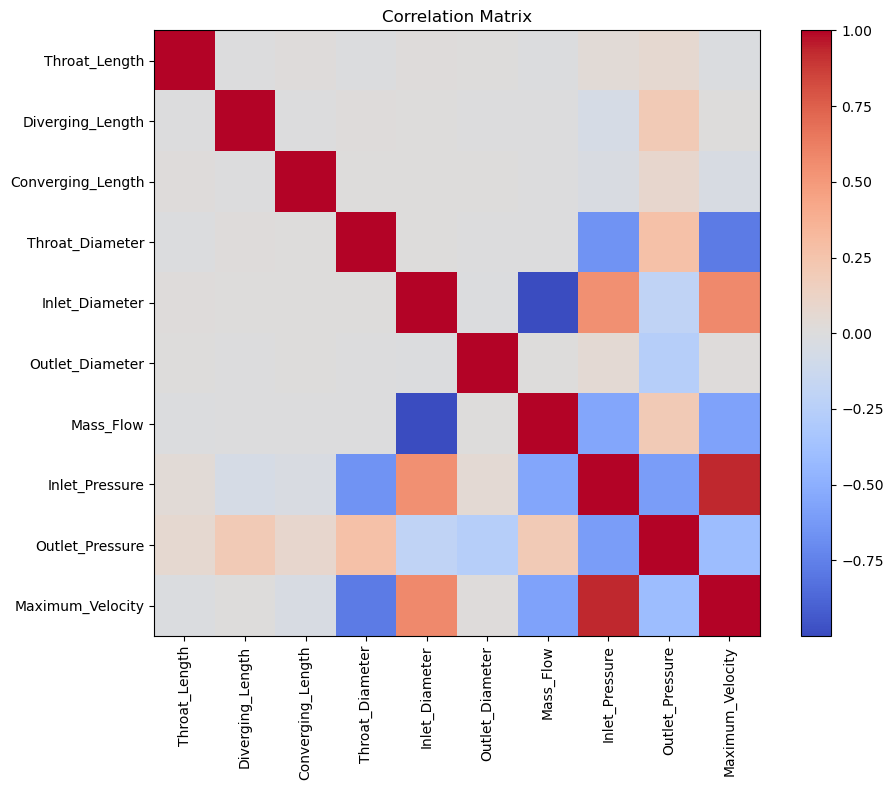

In [10]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr.columns)),
           corr.columns,
           rotation=90)

plt.yticks(range(len(corr.columns)),
           corr.columns)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

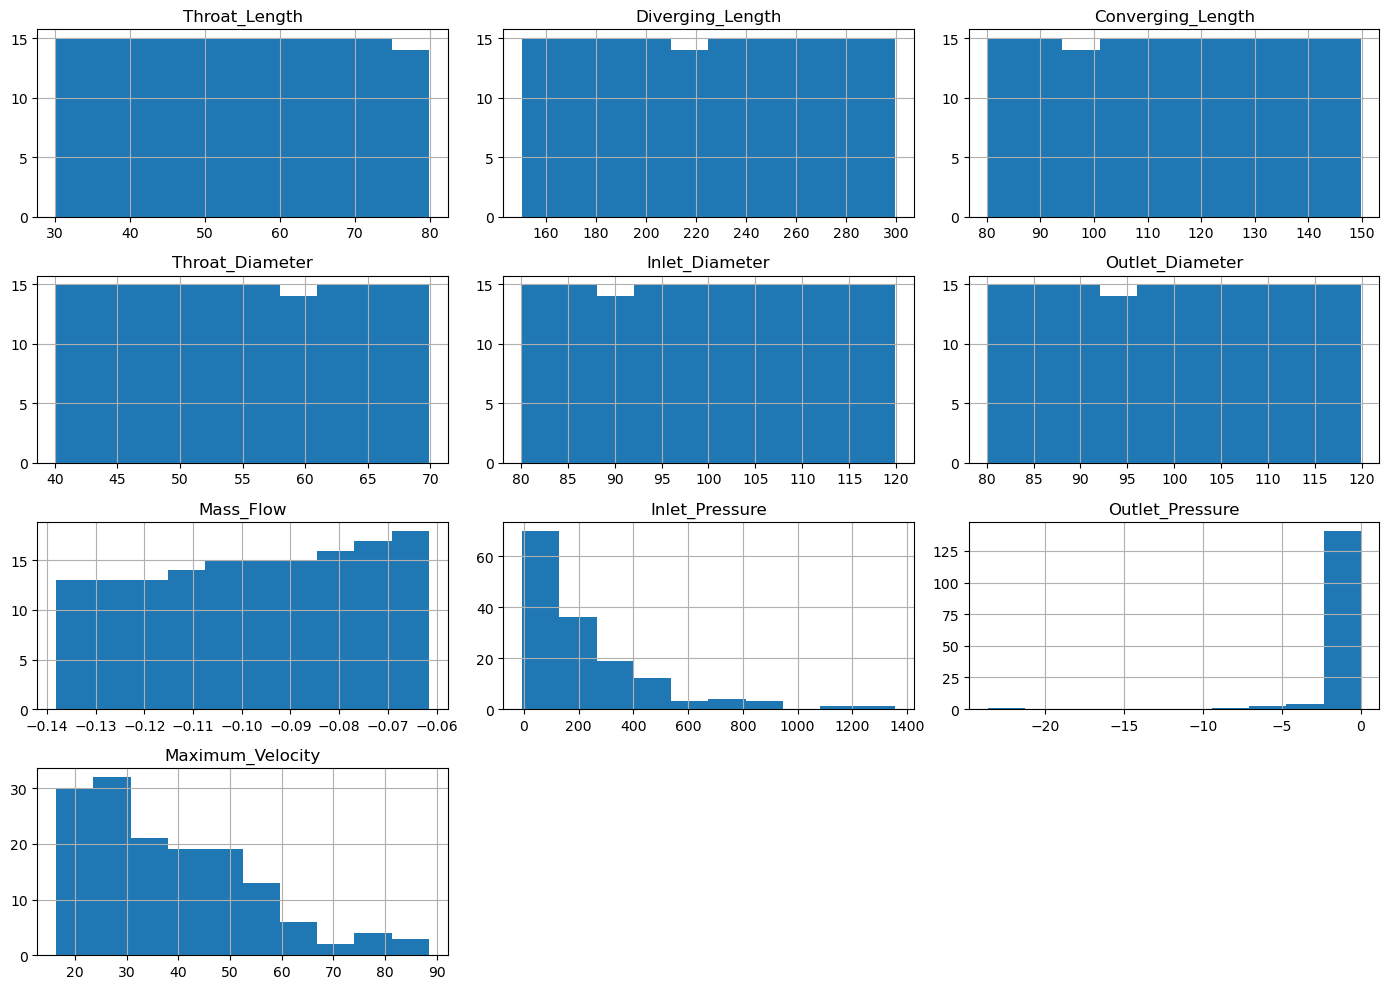

In [11]:
df.hist(figsize=(14,10))

plt.tight_layout()

plt.show()

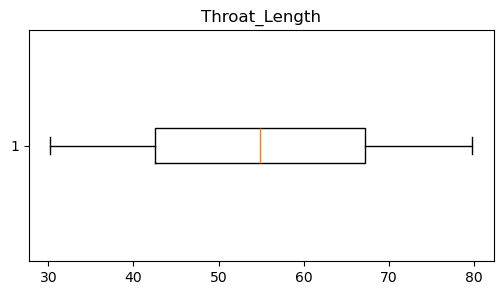

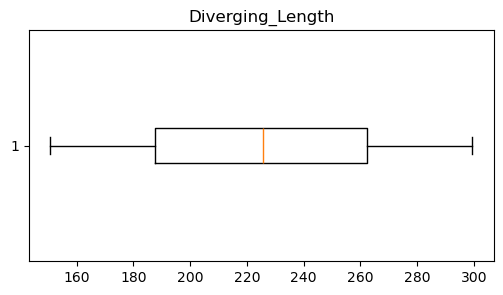

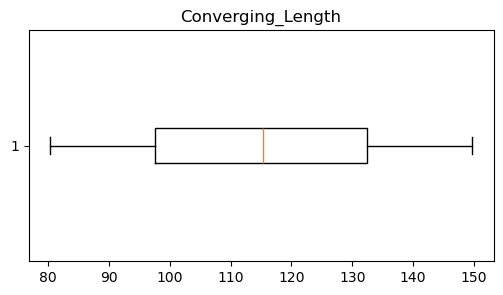

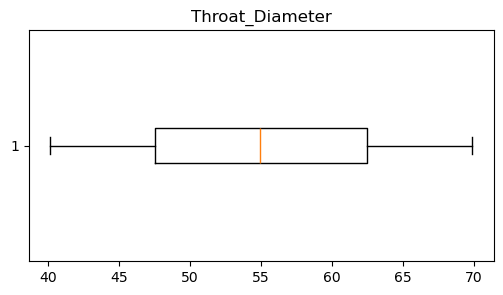

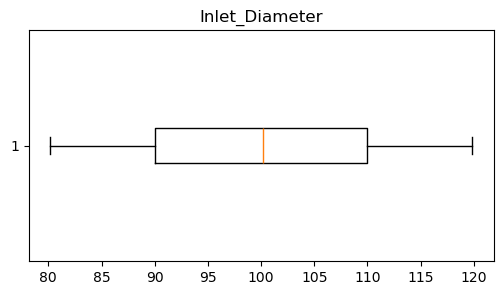

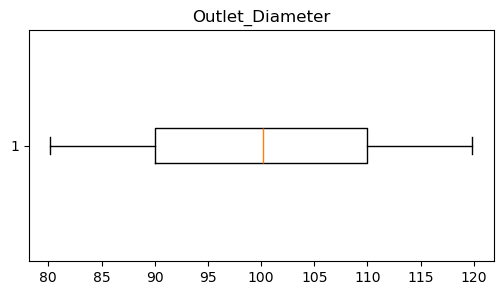

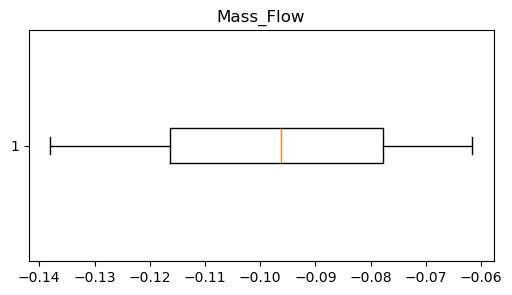

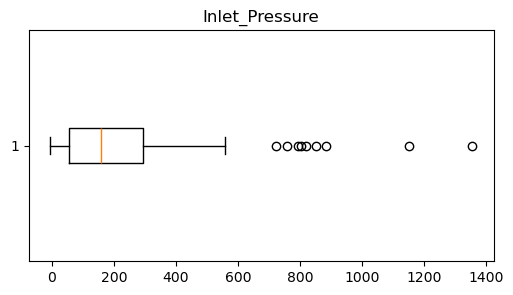

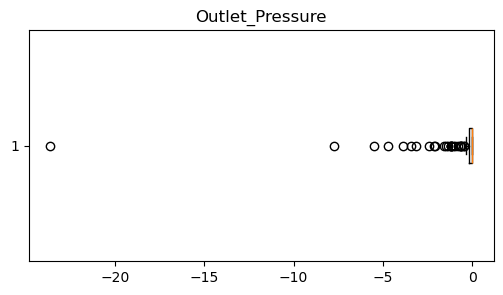

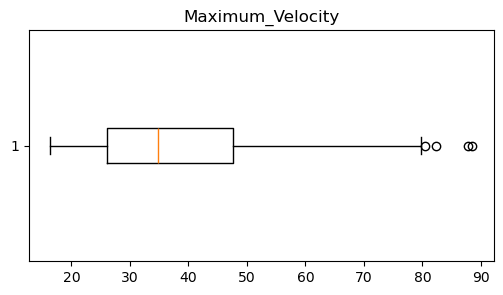

In [12]:
for column in df.columns:

    plt.figure(figsize=(6,3))

    plt.boxplot(df[column], vert=False)

    plt.title(column)

    plt.show()

In [13]:
X_forward = df[[
    "Throat_Length",
    "Diverging_Length",
    "Converging_Length",
    "Throat_Diameter",
    "Inlet_Diameter",
    "Outlet_Diameter"
]]

Y_forward = df[[
    "Mass_Flow",
    "Inlet_Pressure",
    "Outlet_Pressure",
    "Maximum_Velocity"
]]

In [14]:
X_inverse = df[[
    "Mass_Flow",
    "Inlet_Pressure",
    "Outlet_Pressure",
    "Maximum_Velocity"
]]

Y_inverse = df[[
    "Throat_Length",
    "Diverging_Length",
    "Converging_Length",
    "Throat_Diameter",
    "Inlet_Diameter",
    "Outlet_Diameter"
]]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_forward,
    Y_forward,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples : 119
Testing Samples : 30


In [16]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor

rf_forward = MultiOutputRegressor(

    RandomForestRegressor(

        n_estimators=300,
        max_depth=15,
        random_state=42

    )

)

rf_forward.fit(X_train, y_train)

MultiOutputRegressor(estimator=RandomForestRegressor(max_depth=15,
                                                     n_estimators=300,
                                                     random_state=42))

In [17]:
y_pred = rf_forward.predict(X_test)

In [18]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

outputs = Y_forward.columns

for i, output in enumerate(outputs):

    print("="*50)
    print(output)

    r2 = r2_score(y_test.iloc[:,i], y_pred[:,i])

    mae = mean_absolute_error(
        y_test.iloc[:,i],
        y_pred[:,i]
    )

    rmse = np.sqrt(

        mean_squared_error(

            y_test.iloc[:,i],

            y_pred[:,i]

        )

    )

    print("R2 Score :", round(r2,4))
    print("MAE      :", round(mae,4))
    print("RMSE     :", round(rmse,4))

Mass_Flow
R2 Score : 0.9988
MAE      : 0.0006
RMSE     : 0.0008
Inlet_Pressure
R2 Score : 0.936
MAE      : 34.3644
RMSE     : 54.2996
Outlet_Pressure
R2 Score : -7.166
MAE      : 0.5
RMSE     : 1.4488
Maximum_Velocity
R2 Score : 0.942
MAE      : 2.6053
RMSE     : 3.5079


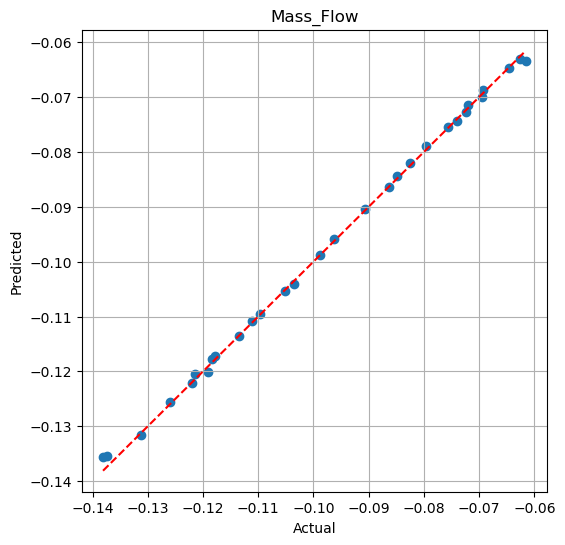

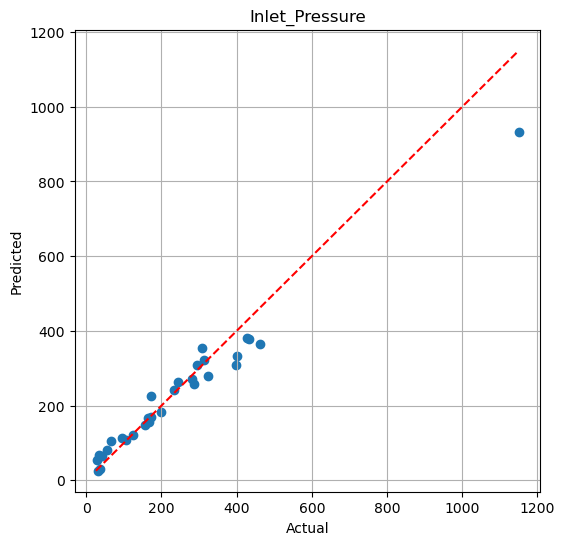

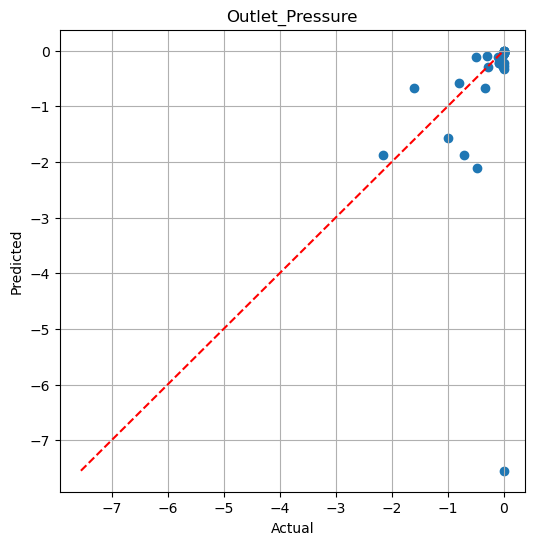

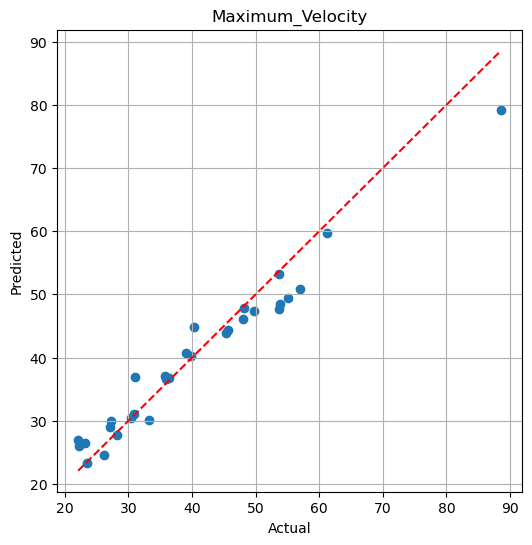

In [19]:
for i, output in enumerate(outputs):

    plt.figure(figsize=(6,6))

    plt.scatter(

        y_test.iloc[:,i],

        y_pred[:,i]

    )

    minimum = min(

        y_test.iloc[:,i].min(),

        y_pred[:,i].min()

    )

    maximum = max(

        y_test.iloc[:,i].max(),

        y_pred[:,i].max()

    )

    plt.plot(

        [minimum, maximum],

        [minimum, maximum],

        'r--'

    )

    plt.xlabel("Actual")

    plt.ylabel("Predicted")

    plt.title(output)

    plt.grid(True)

    plt.show()

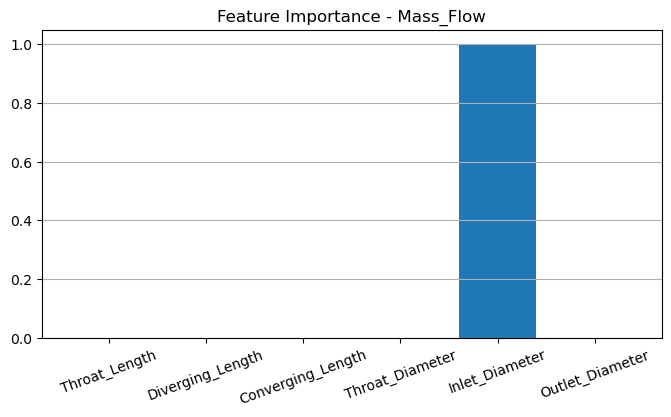

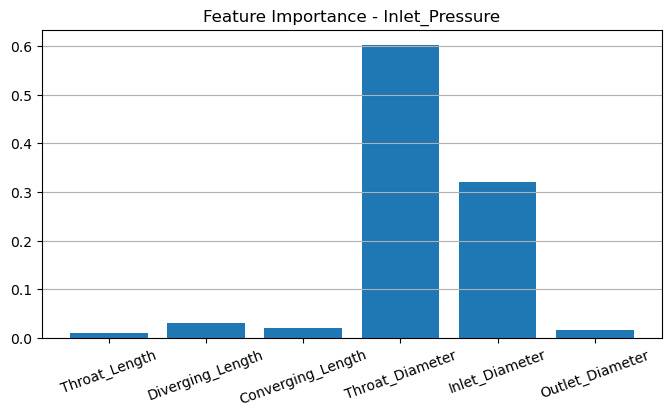

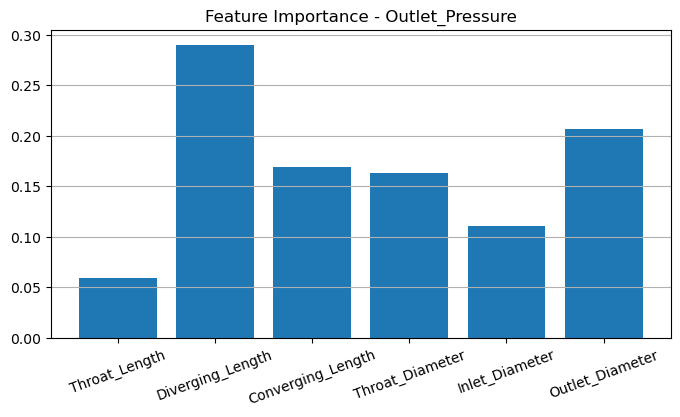

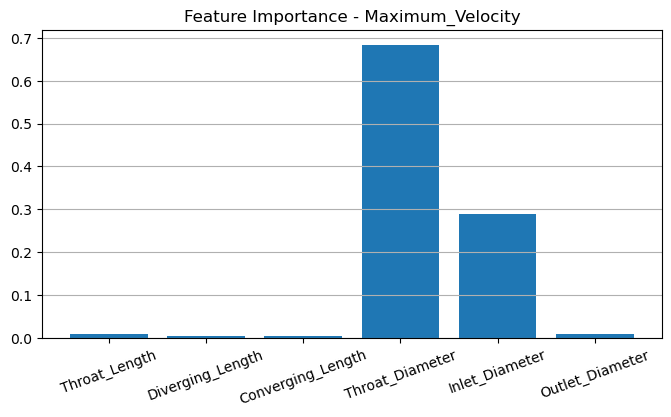

In [21]:
feature_names = X_forward.columns

for i, output in enumerate(outputs):

    importance = rf_forward.estimators_[i].feature_importances_

    plt.figure(figsize=(8,4))

    plt.bar(feature_names, importance)

    plt.xticks(rotation=20)

    plt.title(f"Feature Importance - {output}")

    plt.grid(axis='y')

    plt.show()

In [22]:
import joblib

joblib.dump(

    rf_forward,

    "Forward_Model.pkl"

)

print("Forward Model Saved Successfully")

Forward Model Saved Successfully


In [23]:
new_geometry = pd.DataFrame({

"Throat_Length":[55],
"Diverging_Length":[220],
"Converging_Length":[120],
"Throat_Diameter":[55],
"Inlet_Diameter":[100],
"Outlet_Diameter":[100]

})

prediction = rf_forward.predict(new_geometry)

print("\nPredicted CFD Results\n")

print("Mass Flow Rate :", prediction[0][0])

print("Inlet Pressure :", prediction[0][1])

print("Outlet Pressure :", prediction[0][2])

print("Maximum Velocity :", prediction[0][3])


Predicted CFD Results

Mass Flow Rate : -0.09561577661666668
Inlet Pressure : 147.95443068666637
Outlet Pressure : -0.0108473142223334
Maximum Velocity : 36.36271828000002


In [27]:
# ================================
# INVERSE MODEL (CFD → Geometry)
# ================================

X_inverse = df[[
    "Mass_Flow",
    "Inlet_Pressure",
    "Outlet_Pressure",
    "Maximum_Velocity"
]]

Y_inverse = df[[
    "Throat_Length",
    "Diverging_Length",
    "Converging_Length",
    "Throat_Diameter",
    "Inlet_Diameter",
    "Outlet_Diameter"
]]

print(X_inverse.head())
print()
print(Y_inverse.head())

   Mass_Flow  Inlet_Pressure  Outlet_Pressure  Maximum_Velocity
0  -0.066694       46.697654        -0.001476         26.995272
1  -0.115664       85.990158         0.000000         26.975095
2  -0.129583      193.721620         0.000000         38.072629
3  -0.062081       -6.149937        -0.006353         16.698667
4  -0.096872      247.199060        -1.178567         43.060847

   Throat_Length  Diverging_Length  Converging_Length  Throat_Diameter  \
0      40.166667             292.5         132.966667             51.5   
1      56.833333             251.5         111.966667             68.3   
2      54.500000             258.5         144.166667             60.7   
3      60.833333             291.5         114.766667             63.3   
4      55.166667             209.5          89.100000             49.9   

   Inlet_Diameter  Outlet_Diameter  
0       83.333333       110.533333  
1      109.733333        97.733333  
2      116.133333        92.666667  
3       80.400000     

In [28]:
from sklearn.model_selection import train_test_split

X_train2, X_test2, Y_train2, Y_test2 = train_test_split(
    X_inverse,
    Y_inverse,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", X_train2.shape[0])
print("Testing Samples :", X_test2.shape[0])

Training Samples : 119
Testing Samples : 30


In [29]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor

rf_inverse = MultiOutputRegressor(

    RandomForestRegressor(

        n_estimators=300,
        random_state=42

    )

)

rf_inverse.fit(X_train2, Y_train2)

print("Inverse Model Trained Successfully!")

Inverse Model Trained Successfully!


In [30]:
Y_pred2 = rf_inverse.predict(X_test2)

In [31]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import numpy as np

outputs = Y_inverse.columns

for i, output in enumerate(outputs):

    print("--------------------------------")
    print(output)
    print("--------------------------------")

    r2 = r2_score(
        Y_test2.iloc[:, i],
        Y_pred2[:, i]
    )

    rmse = np.sqrt(

        mean_squared_error(

            Y_test2.iloc[:, i],
            Y_pred2[:, i]

        )

    )

    print("R2 Score :", round(r2,4))
    print("RMSE :", round(rmse,4))

--------------------------------
Throat_Length
--------------------------------
R2 Score : 0.1653
RMSE : 12.6756
--------------------------------
Diverging_Length
--------------------------------
R2 Score : -0.4412
RMSE : 53.0512
--------------------------------
Converging_Length
--------------------------------
R2 Score : -0.2625
RMSE : 23.0038
--------------------------------
Throat_Diameter
--------------------------------
R2 Score : 0.9537
RMSE : 1.6179
--------------------------------
Inlet_Diameter
--------------------------------
R2 Score : 0.9992
RMSE : 0.3492
--------------------------------
Outlet_Diameter
--------------------------------
R2 Score : 0.7207
RMSE : 6.0481


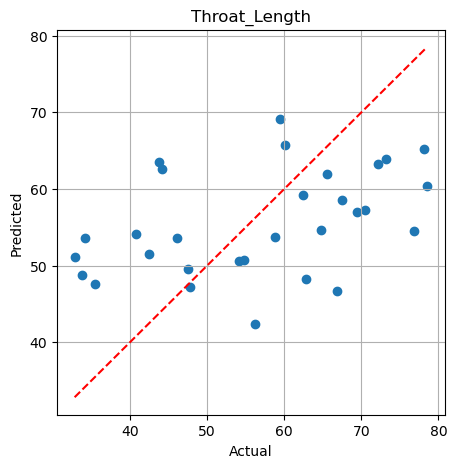

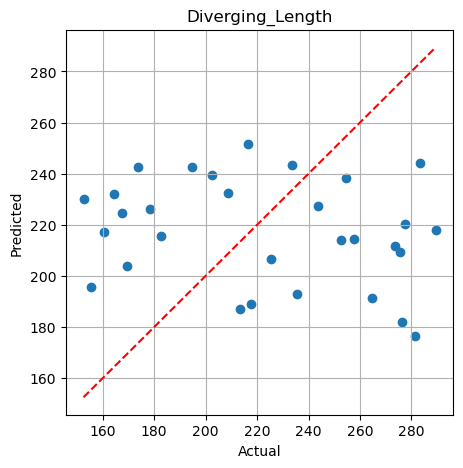

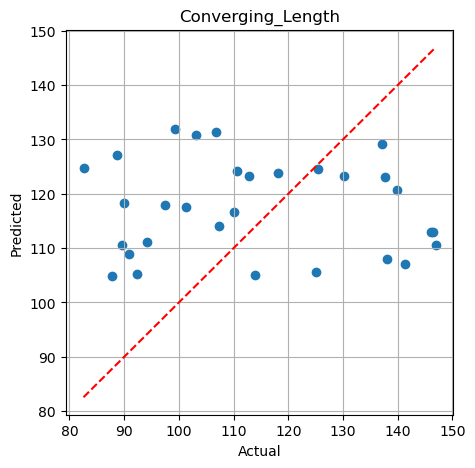

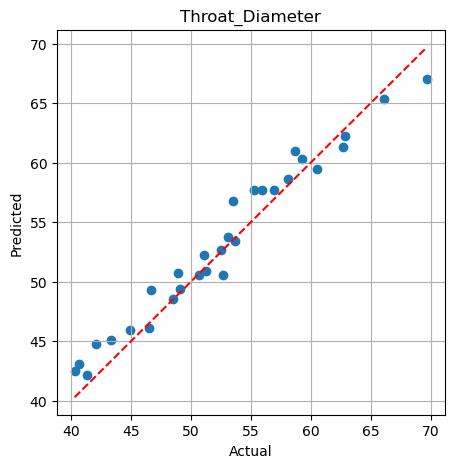

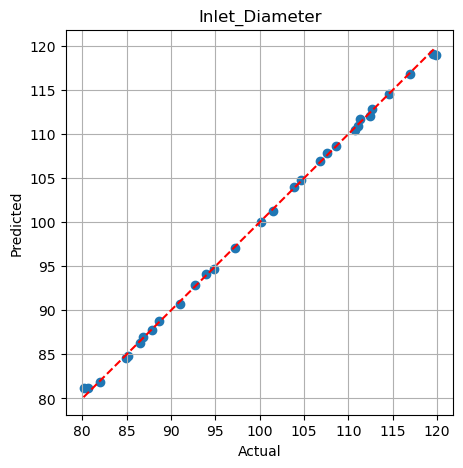

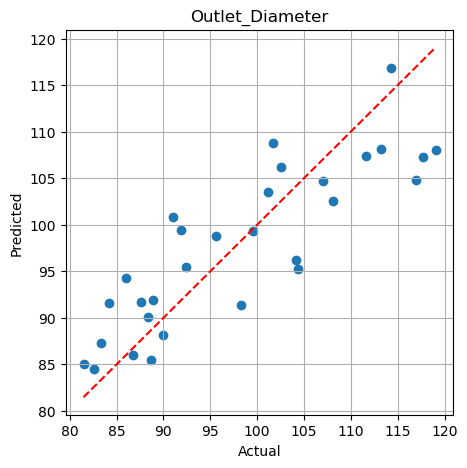

In [32]:
import matplotlib.pyplot as plt

for i, output in enumerate(outputs):

    plt.figure(figsize=(5,5))

    plt.scatter(
        Y_test2.iloc[:,i],
        Y_pred2[:,i]
    )

    minimum = min(
        Y_test2.iloc[:,i].min(),
        Y_pred2[:,i].min()
    )

    maximum = max(
        Y_test2.iloc[:,i].max(),
        Y_pred2[:,i].max()
    )

    plt.plot(
        [minimum, maximum],
        [minimum, maximum],
        'r--'
    )

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(output)

    plt.grid(True)

    plt.show()

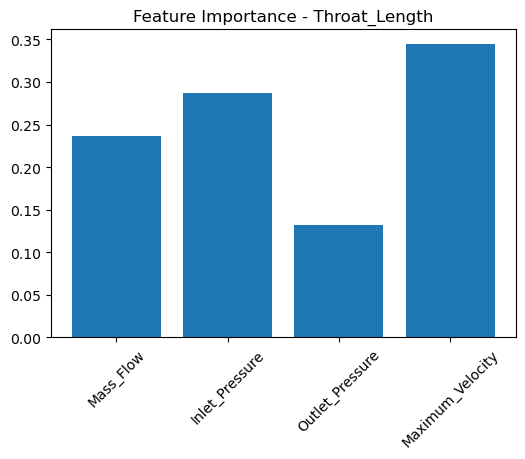

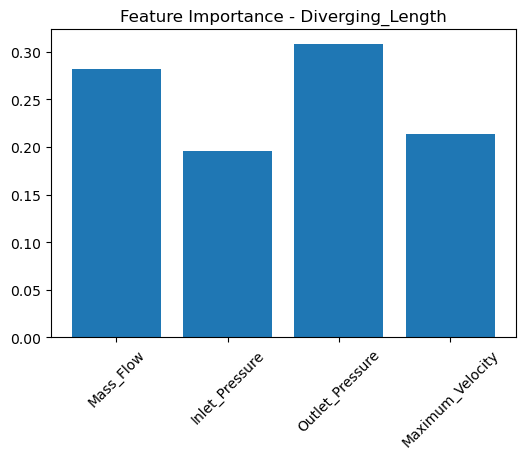

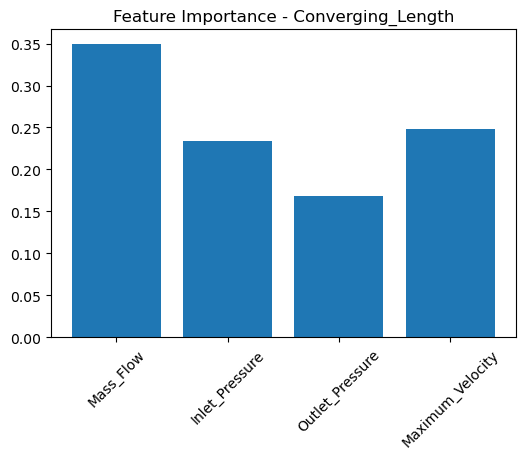

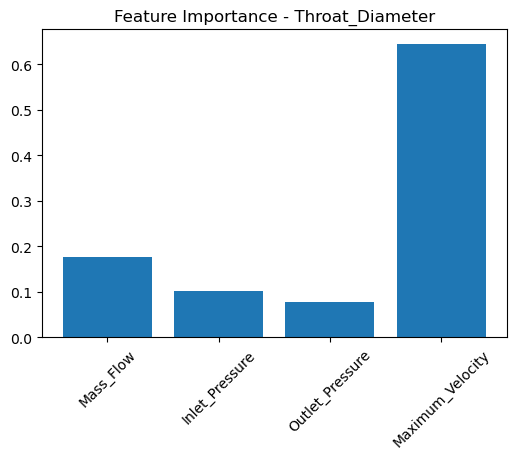

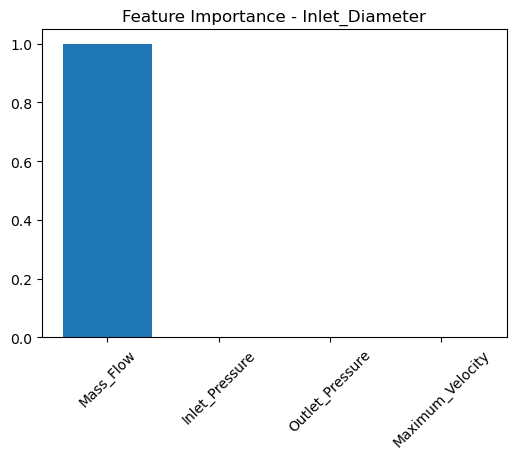

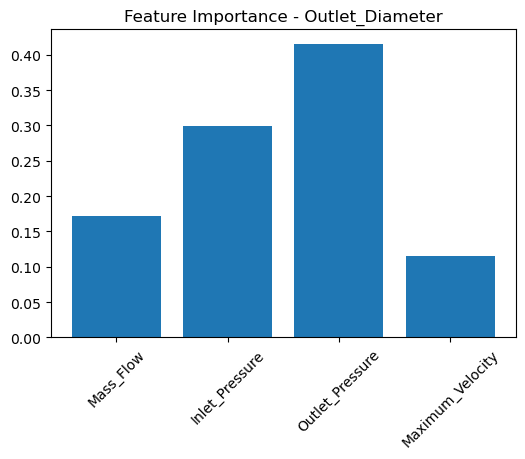

In [33]:
feature_names = X_inverse.columns

for i, output in enumerate(Y_inverse.columns):

    importance = rf_inverse.estimators_[i].feature_importances_

    plt.figure(figsize=(6,4))

    plt.bar(feature_names, importance)

    plt.title(f"Feature Importance - {output}")

    plt.xticks(rotation=45)

    plt.show()

In [34]:
import joblib

joblib.dump(

    rf_inverse,

    "Inverse_Model.pkl"

)

print("Inverse Model Saved Successfully!")

Inverse Model Saved Successfully!


In [35]:
desired_cfd = pd.DataFrame({

    "Mass_Flow":[-0.10],
    "Inlet_Pressure":[150],
    "Outlet_Pressure":[-0.01],
    "Maximum_Velocity":[40]

})

geometry = rf_inverse.predict(desired_cfd)

print("Recommended Venturi Geometry\n")

print("Throat Length :", geometry[0][0])
print("Diverging Length :", geometry[0][1])
print("Converging Length :", geometry[0][2])
print("Throat Diameter :", geometry[0][3])
print("Inlet Diameter :", geometry[0][4])
print("Outlet Diameter :", geometry[0][5])

Recommended Venturi Geometry

Throat Length : 47.13555555555552
Diverging Length : 234.90999999999985
Converging Length : 111.61355555555527
Throat Diameter : 52.05933333333314
Inlet Diameter : 102.05422222222178
Outlet Diameter : 106.77244444444419


In [36]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.multioutput import MultiOutputRegressor

et_model = MultiOutputRegressor(
    ExtraTreesRegressor(
        n_estimators=300,
        random_state=42
    )
)

et_model.fit(X_train, y_train)

print("Extra Trees Model Trained Successfully!")

Extra Trees Model Trained Successfully!


In [37]:
y_pred_et = et_model.predict(X_test)

In [40]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

outputs = y_train.columns

for i, output in enumerate(outputs):

    print("="*60)
    print(output)

    r2 = r2_score(
        y_test.iloc[:,i],
        y_pred_et[:,i]
    )

    mae = mean_absolute_error(
        y_test.iloc[:,i],
        y_pred_et[:,i]
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test.iloc[:,i],
            y_pred_et[:,i]
        )
    )

    print("R² Score :", round(r2,4))
    print("MAE      :", round(mae,4))
    print("RMSE     :", round(rmse,4))

Mass_Flow
R² Score : 0.9994
MAE      : 0.0003
RMSE     : 0.0006
Inlet_Pressure
R² Score : 0.9444
MAE      : 31.9003
RMSE     : 50.5963
Outlet_Pressure
R² Score : -0.9218
MAE      : 0.3927
RMSE     : 0.7028
Maximum_Velocity
R² Score : 0.9752
MAE      : 1.4936
RMSE     : 2.2956


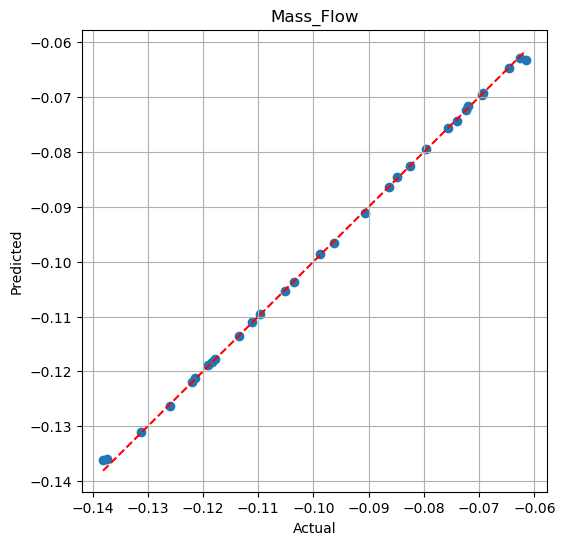

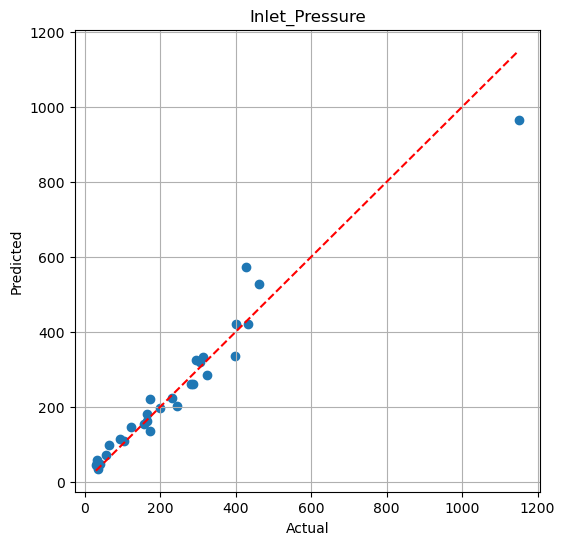

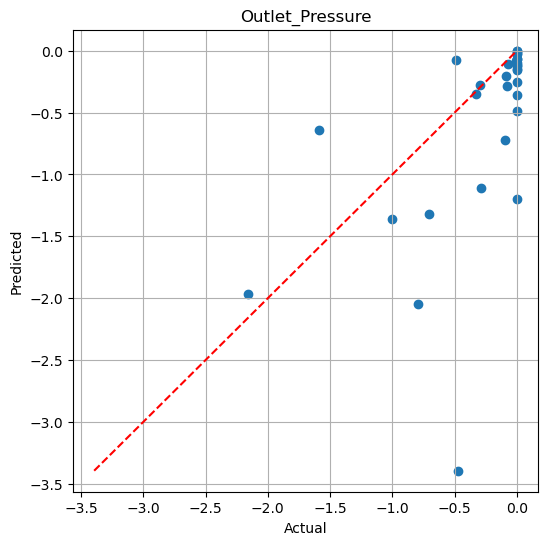

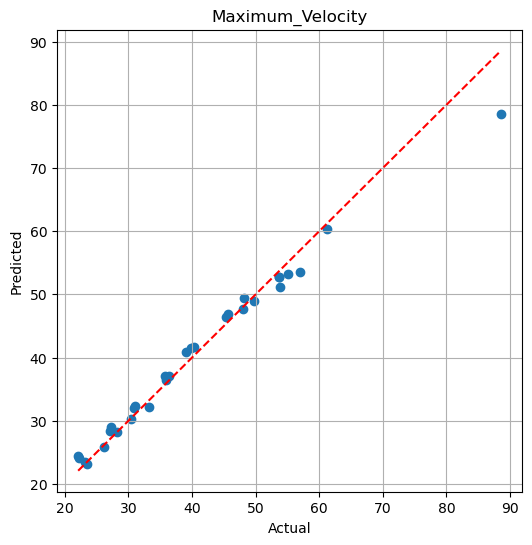

In [41]:
for i, output in enumerate(outputs):

    plt.figure(figsize=(6,6))

    plt.scatter(
        y_test.iloc[:,i],
        y_pred_et[:,i]
    )

    minimum=min(
        y_test.iloc[:,i].min(),
        y_pred_et[:,i].min()
    )

    maximum=max(
        y_test.iloc[:,i].max(),
        y_pred_et[:,i].max()
    )

    plt.plot(
        [minimum,maximum],
        [minimum,maximum],
        'r--'
    )

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(output)

    plt.grid(True)

    plt.show()

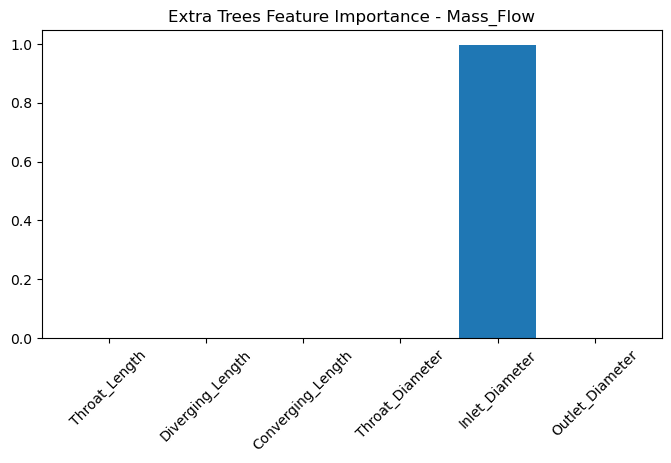

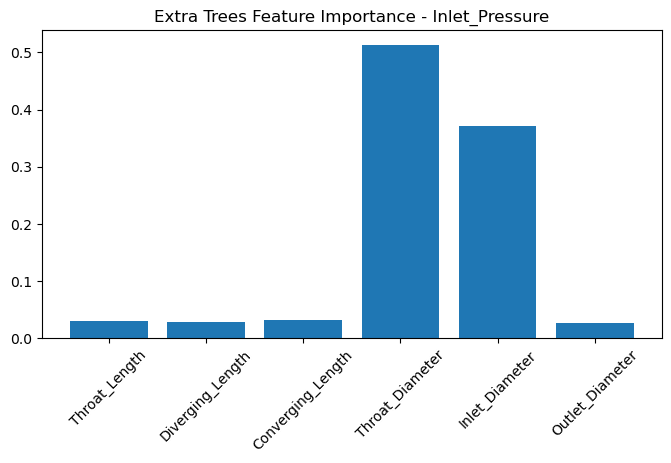

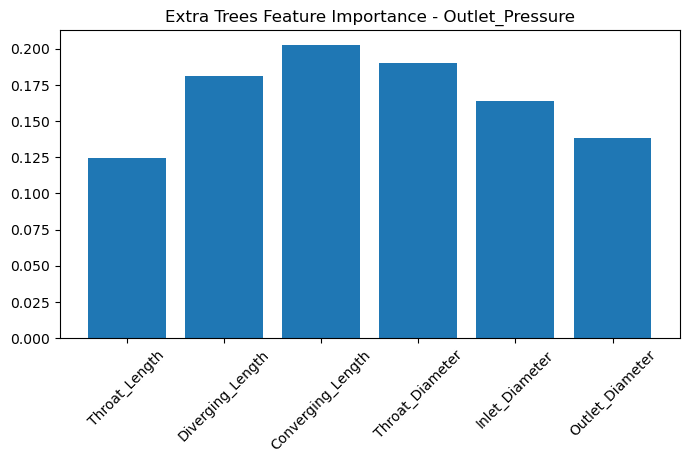

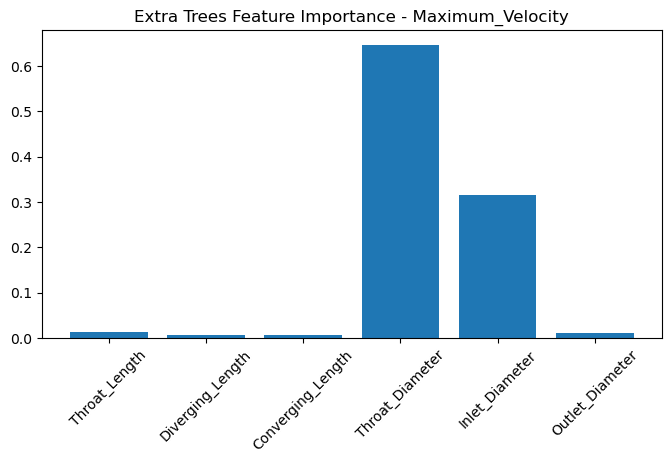

In [42]:
feature_names = X_train.columns

for i, output in enumerate(outputs):

    importance = et_model.estimators_[i].feature_importances_

    plt.figure(figsize=(8,4))

    plt.bar(feature_names, importance)

    plt.xticks(rotation=45)

    plt.title(f"Extra Trees Feature Importance - {output}")

    plt.show()

In [43]:
import joblib

joblib.dump(
    et_model,
    "ExtraTrees_Model.pkl"
)

print("Extra Trees Model Saved Successfully!")

Extra Trees Model Saved Successfully!


In [44]:
new_geometry = pd.DataFrame({

    "Throat_Length":[55],
    "Diverging_Length":[220],
    "Converging_Length":[120],
    "Throat_Diameter":[55],
    "Inlet_Diameter":[100],
    "Outlet_Diameter":[100]

})

prediction = et_model.predict(new_geometry)

print("\nPredicted CFD Results\n")

print("Mass Flow :", prediction[0][0])
print("Inlet Pressure :", prediction[0][1])
print("Outlet Pressure :", prediction[0][2])
print("Maximum Velocity :", prediction[0][3])


Predicted CFD Results

Mass Flow : -0.09614476696999982
Inlet Pressure : 150.78864673999973
Outlet Pressure : -0.06477308097299994
Maximum Velocity : 35.41795772333334


In [45]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

gb_model = MultiOutputRegressor(

    GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

)

gb_model.fit(X_train, y_train)

print("Gradient Boosting Model Trained Successfully!")

Gradient Boosting Model Trained Successfully!


In [46]:
y_pred_gb = gb_model.predict(X_test)

In [47]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

outputs = y_train.columns

for i, output in enumerate(outputs):

    print("="*60)
    print(output)

    r2 = r2_score(
        y_test.iloc[:,i],
        y_pred_gb[:,i]
    )

    mae = mean_absolute_error(
        y_test.iloc[:,i],
        y_pred_gb[:,i]
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test.iloc[:,i],
            y_pred_gb[:,i]
        )
    )

    print("R² Score :", round(r2,4))
    print("MAE      :", round(mae,4))
    print("RMSE     :", round(rmse,4))

Mass_Flow
R² Score : 0.9992
MAE      : 0.0006
RMSE     : 0.0007
Inlet_Pressure
R² Score : 0.9366
MAE      : 34.211
RMSE     : 54.0528
Outlet_Pressure
R² Score : -22.2262
MAE      : 0.6236
RMSE     : 2.4433
Maximum_Velocity
R² Score : 0.9617
MAE      : 2.2779
RMSE     : 2.8503


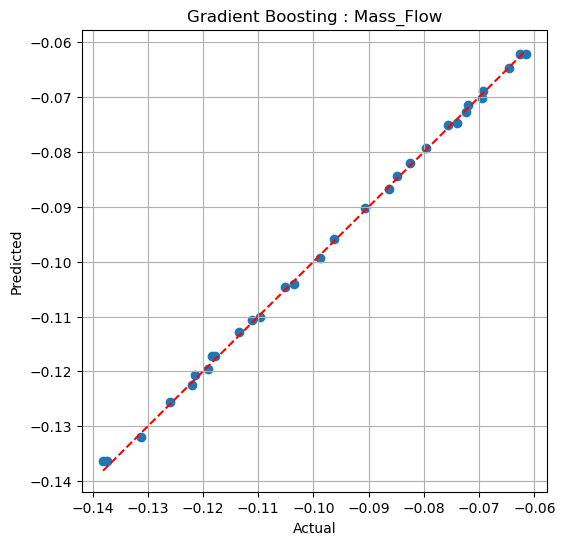

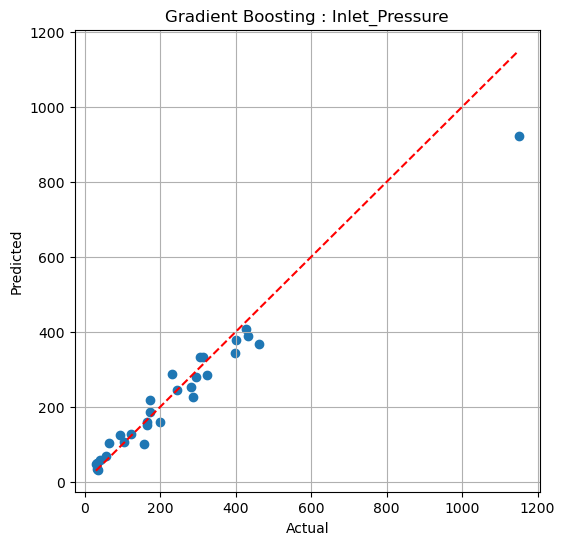

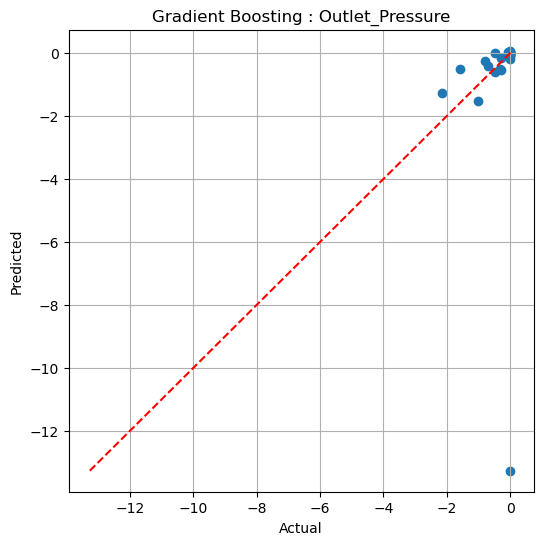

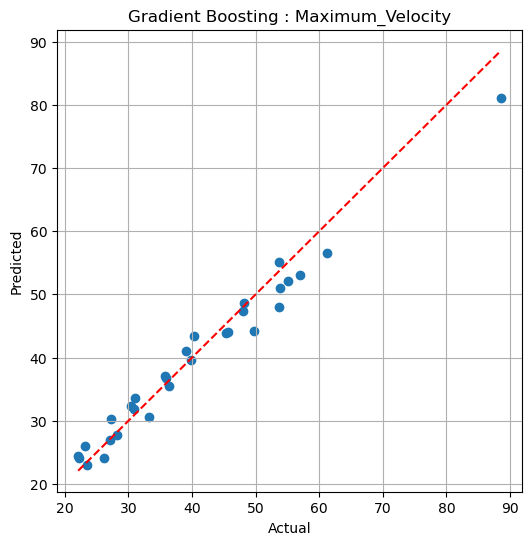

In [48]:
for i, output in enumerate(outputs):

    plt.figure(figsize=(6,6))

    plt.scatter(
        y_test.iloc[:,i],
        y_pred_gb[:,i]
    )

    minimum=min(
        y_test.iloc[:,i].min(),
        y_pred_gb[:,i].min()
    )

    maximum=max(
        y_test.iloc[:,i].max(),
        y_pred_gb[:,i].max()
    )

    plt.plot(
        [minimum,maximum],
        [minimum,maximum],
        'r--'
    )

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Gradient Boosting : {output}")

    plt.grid(True)

    plt.show()

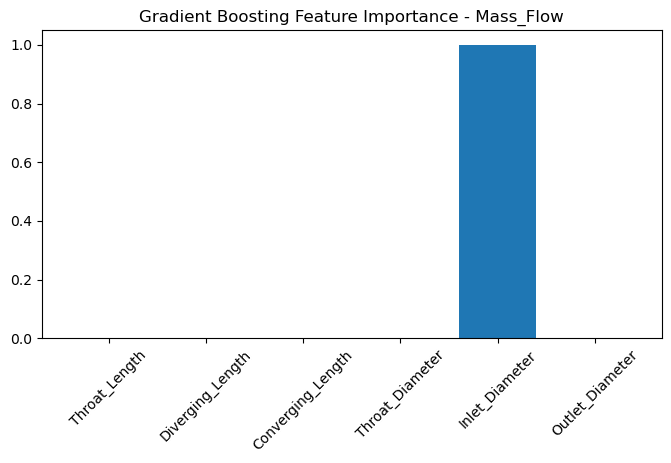

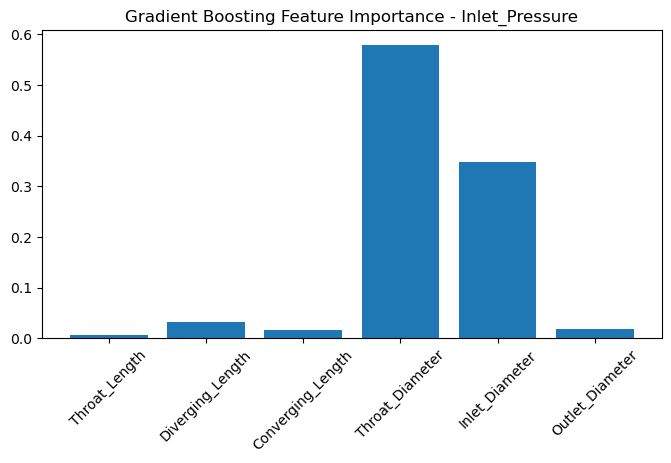

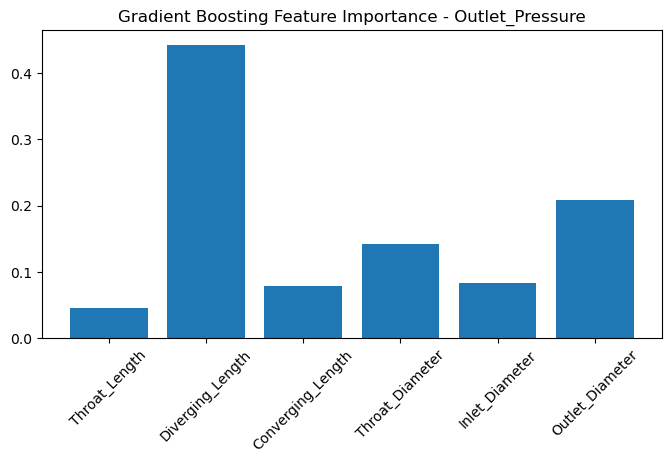

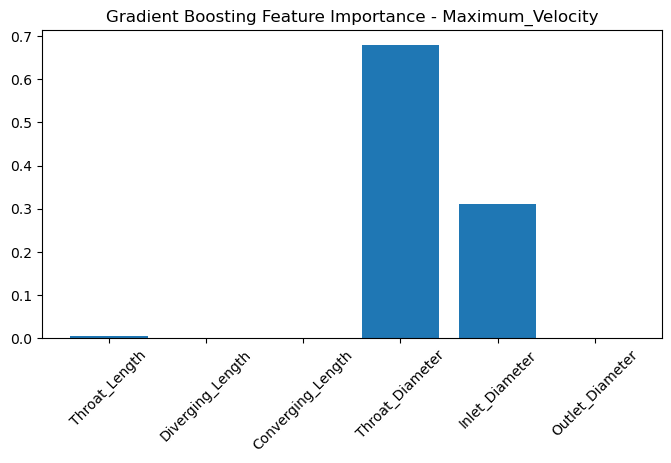

In [49]:
feature_names = X_train.columns

for i, output in enumerate(outputs):

    importance = gb_model.estimators_[i].feature_importances_

    plt.figure(figsize=(8,4))

    plt.bar(feature_names, importance)

    plt.xticks(rotation=45)

    plt.title(f"Gradient Boosting Feature Importance - {output}")

    plt.show()

In [50]:
import joblib

joblib.dump(
    gb_model,
    "GradientBoosting_Model.pkl"
)

print("Gradient Boosting Model Saved Successfully!")

Gradient Boosting Model Saved Successfully!


In [51]:
new_geometry = pd.DataFrame({

    "Throat_Length":[55],
    "Diverging_Length":[220],
    "Converging_Length":[120],
    "Throat_Diameter":[55],
    "Inlet_Diameter":[100],
    "Outlet_Diameter":[100]

})

prediction = gb_model.predict(new_geometry)

print("\nPredicted CFD Results\n")

print("Mass Flow        :", prediction[0][0])
print("Inlet Pressure   :", prediction[0][1])
print("Outlet Pressure  :", prediction[0][2])
print("Maximum Velocity :", prediction[0][3])


Predicted CFD Results

Mass Flow        : -0.09583453883462957
Inlet Pressure   : 123.34589626892232
Outlet Pressure  : 0.017688393666669334
Maximum Velocity : 35.353200911127026


In [52]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

models = {
    "Random Forest": rf_forward,
    "Extra Trees": et_model,
    "Gradient Boosting": gb_model
}

results = []

for model_name, model in models.items():

    pred = model.predict(X_test)

    for i, output in enumerate(y_test.columns):

        r2 = r2_score(y_test.iloc[:, i], pred[:, i])
        mae = mean_absolute_error(y_test.iloc[:, i], pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], pred[:, i]))

        results.append([
            model_name,
            output,
            r2,
            mae,
            rmse
        ])

comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Output",
        "R2 Score",
        "MAE",
        "RMSE"
    ]
)

comparison

,Model,Output,R2 Score,MAE,RMSE
0,Random Forest,Mass_Flow,0.998837,0.000577,0.000805
1,Random Forest,Inlet_Pressure,0.936012,34.364421,54.299642
2,Random Forest,Outlet_Pressure,-7.165953,0.499989,1.448768
3,Random Forest,Maximum_Velocity,0.941999,2.605293,3.507936
4,Extra Trees,Mass_Flow,0.999418,0.000319,0.000570
5,Extra Trees,Inlet_Pressure,0.944443,31.900250,50.596279
6,Extra Trees,Outlet_Pressure,-0.921803,0.392719,0.702829
7,Extra Trees,Maximum_Velocity,0.975162,1.493582,2.295580
8,Gradient Boosting,Mass_Flow,0.999229,0.000590,0.000656
9,Gradient Boosting,Inlet_Pressure,0.936592,34.210990,54.052845


In [53]:
comparison.to_excel(
    "Model_Comparison.xlsx",
    index=False
)

print("Comparison Saved Successfully!")

Comparison Saved Successfully!


In [54]:
best = comparison.loc[
    comparison.groupby("Output")["R2 Score"].idxmax()
]

print(best)

         Model            Output  R2 Score        MAE       RMSE
5  Extra Trees    Inlet_Pressure  0.944443  31.900250  50.596279
4  Extra Trees         Mass_Flow  0.999418   0.000319   0.000570
7  Extra Trees  Maximum_Velocity  0.975162   1.493582   2.295580
6  Extra Trees   Outlet_Pressure -0.921803   0.392719   0.702829


In [55]:
average = comparison.groupby("Model")[["R2 Score","MAE","RMSE"]].mean()

average

,R2 Score,MAE,RMSE
Model,,,
Extra Trees,0.499305,8.446717,13.398814
Gradient Boosting,-4.832157,9.278283,14.836785
Random Forest,-1.072276,9.367570,14.814288


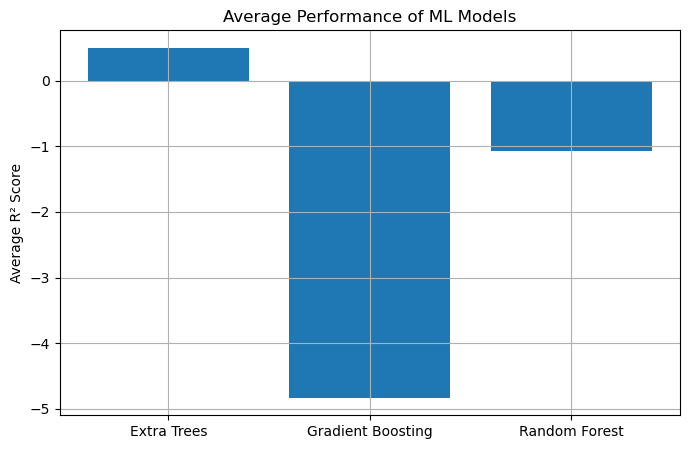

In [56]:
plt.figure(figsize=(8,5))

plt.bar(
    average.index,
    average["R2 Score"]
)

plt.ylabel("Average R² Score")
plt.title("Average Performance of ML Models")

plt.grid(True)

plt.show()

In [57]:
import joblib

joblib.dump(et_model, "Venturi_AI_Model.pkl")

print("Best Model Saved Successfully!")

Best Model Saved Successfully!


In [58]:
import joblib

model = joblib.load("Venturi_AI_Model.pkl")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [59]:
import pandas as pd

geometry = pd.DataFrame({

    "Throat_Length":[55],
    "Diverging_Length":[220],
    "Converging_Length":[120],
    "Throat_Diameter":[55],
    "Inlet_Diameter":[100],
    "Outlet_Diameter":[100]

})

prediction = model.predict(geometry)

print("Mass Flow :",prediction[0][0])
print("Inlet Pressure :",prediction[0][1])
print("Outlet Pressure :",prediction[0][2])
print("Maximum Velocity :",prediction[0][3])

Mass Flow : -0.09614476696999982
Inlet Pressure : 150.78864673999973
Outlet Pressure : -0.06477308097299994
Maximum Velocity : 35.41795772333334


In [60]:
def predict_cfd(throat,
                diverging,
                converging,
                throat_dia,
                inlet_dia,
                outlet_dia):

    geometry = pd.DataFrame({

        "Throat_Length":[throat],
        "Diverging_Length":[diverging],
        "Converging_Length":[converging],
        "Throat_Diameter":[throat_dia],
        "Inlet_Diameter":[inlet_dia],
        "Outlet_Diameter":[outlet_dia]

    })

    prediction = model.predict(geometry)

    print("="*50)
    print("Predicted CFD Results")
    print("="*50)

    print("Mass Flow        :",prediction[0][0])
    print("Inlet Pressure   :",prediction[0][1])
    print("Outlet Pressure  :",prediction[0][2])
    print("Maximum Velocity :",prediction[0][3])

In [61]:
inverse_model = joblib.load("Inverse_Model.pkl")

def recommend_geometry(massflow,
                       pinlet,
                       poutlet,
                       vmax):

    desired = pd.DataFrame({

        "Mass_Flow":[massflow],
        "Inlet_Pressure":[pinlet],
        "Outlet_Pressure":[poutlet],
        "Maximum_Velocity":[vmax]

    })

    geometry = inverse_model.predict(desired)

    print("="*50)
    print("Recommended Geometry")
    print("="*50)

    print("Throat Length      :",geometry[0][0])
    print("Diverging Length   :",geometry[0][1])
    print("Converging Length  :",geometry[0][2])
    print("Throat Diameter    :",geometry[0][3])
    print("Inlet Diameter     :",geometry[0][4])
    print("Outlet Diameter    :",geometry[0][5])

In [62]:
recommend_geometry(
    -0.10,
    180,
    -0.02,
    45
)

Recommended Geometry
Throat Length      : 57.07111111111108
Diverging Length   : 238.64666666666656
Converging Length  : 109.66599999999994
Throat Diameter    : 49.68533333333334
Inlet Diameter     : 102.05244444444398
Outlet Diameter    : 104.55022222222203
